(1, 16, 49, 49)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


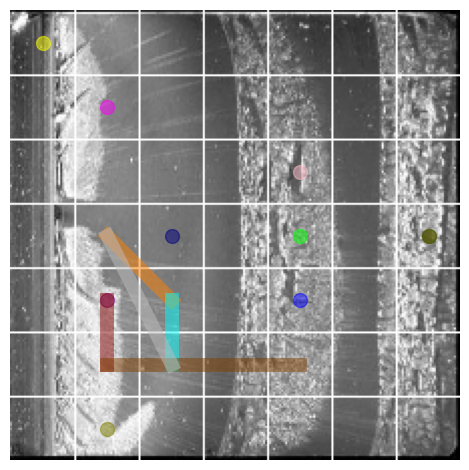

In [8]:
import numpy as np
import pandas as pd 
import pickle as pkl
import cv2
import matplotlib.pyplot as plt

# color
colors = [
    (1.0, 0.0, 0.0, 0.5),   # 赤
    (0.0, 1.0, 0.0, 0.5),   # 緑
    (0.0, 0.0, 1.0, 0.5),   # 青
    (1.0, 1.0, 0.0, 0.5),   # 黄
    (1.0, 0.5, 0.0, 0.5),   # オレンジ
    (0.5, 0.0, 0.5, 0.5),   # 紫
    (0.0, 1.0, 1.0, 0.5),   # シアン
    (1.0, 0.0, 1.0, 0.5),   # マゼンタ
    (0.5, 0.5, 0.5, 0.5),   # グレー
    (1.0, 0.75, 0.8, 0.5),  # ピンク
    (0.0, 0.5, 0.0, 0.5),   # ダークグリーン
    (0.5, 0.0, 0.0, 0.5),   # ダークレッド
    (0.0, 0.0, 0.5, 0.5),   # ダークブルー
    (0.5, 0.5, 0.0, 0.5),   # オリーブ
    (0.5, 0.25, 0.0, 0.5),  # ブラウン
    (0.75, 0.75, 0.75, 0.5) # ライトグレー
]

# data
i = 101783
ad_npy = np.load(f'./Causal_Analysis/data/aw_{i}_bootstrap.npy')
print(ad_npy.shape)
vit_oof = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed42_bootstrap_oof_df.csv')\
    .sort_values(by='Id').reset_index(drop=True)
# ix = vit_oof[vit_oof['Id'] == i].index[0]

img_y, img_x = 224, 224
step = 32
path = '/home/yamanaka/Master_research/Mototake_Analysis/VGG+GP/imagedata/' + str(i) + '.jpg'
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (img_x, img_y))
img[step:img_y:step, :, :] = 255
img[:, step:img_x:step, :] = 255

for j in range(16):
    ad = ad_npy[0][j]
    ad_max = ad.max()
    xy = np.argmax(ad) 
    x, y = np.unravel_index(np.argmax(ad, axis=None), ad.shape)
    xi, xj = x%7, x//7
    yi, yj = y%7, y//7

    if x == y: 
        plt.plot((16+(32*xi)), (16+(32*xj)), color=colors[j], marker = 'o', markersize=10)
    else:
        plt.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=int(10))
plt.imshow(img)
plt.axis('off')

plt.tight_layout()
plt.savefig("./Figure/aw_surface1.eps")
plt.show()

Using GPU
Doing Attention Rollout 101783


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


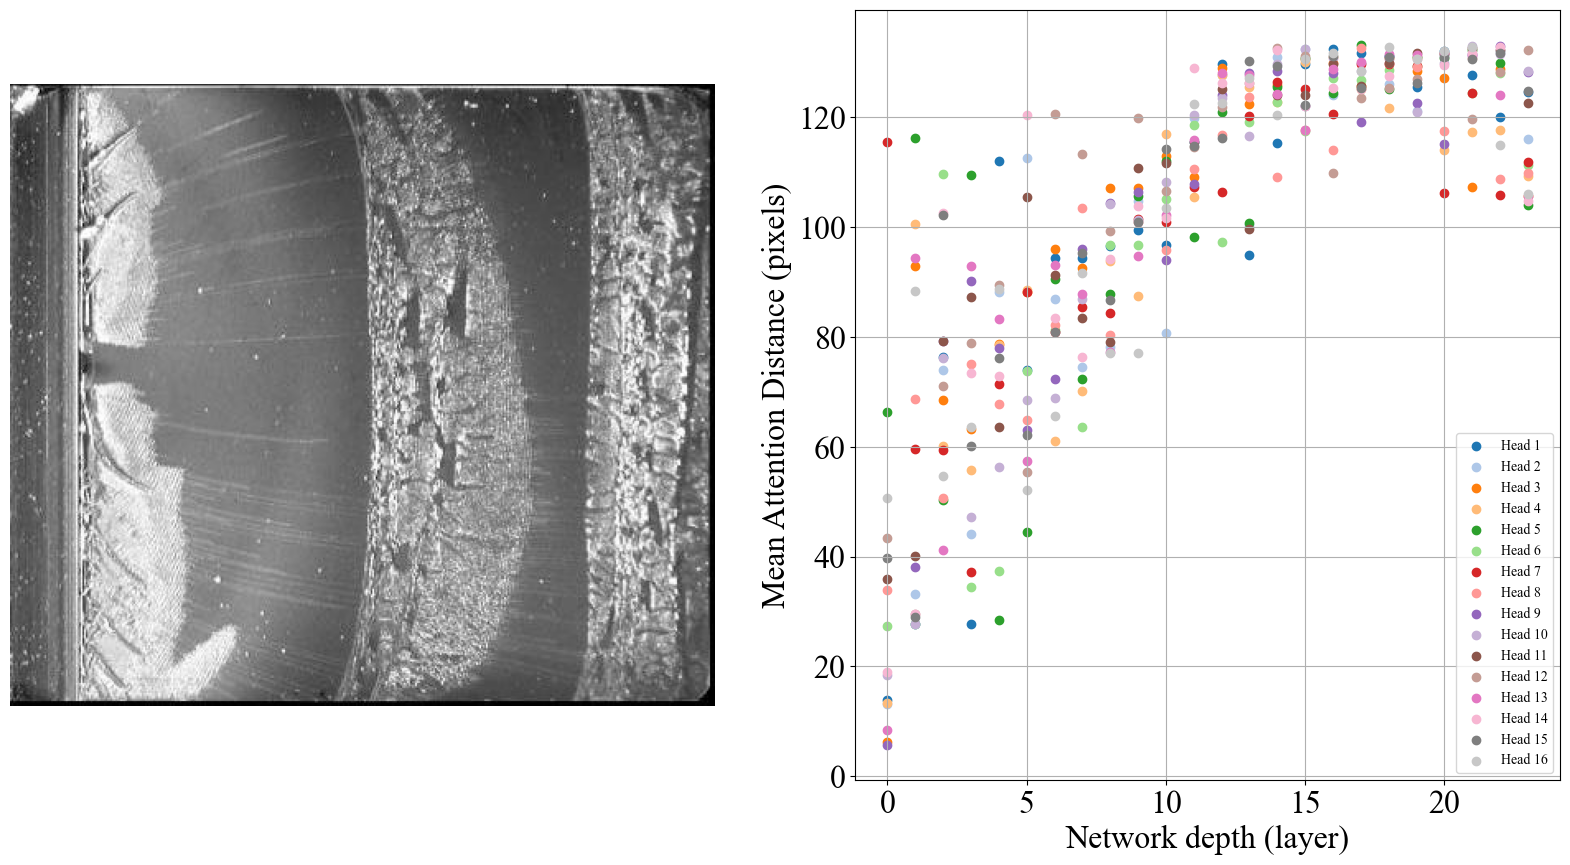

In [ ]:
# ====================================================
# Library
# ====================================================
import os
import sys
import pickle as pkl
import argparse
import sys
import warnings

import pandas as pd
import numpy as np
import cv2
from matplotlib import font_manager as fm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms
import timm
from attention import VITAttention
from vit_grad_rollout import VITAttentionGradRollout

sys.path.append('../input/pytorch-image-models/pytorch-image-models-master')
warnings.filterwarnings('ignore')

# フォントの設定
font_path = '/home/yamanaka/Master_research/Times New Roman.ttf'  
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['figure.figsize'] = 17,5
# plt.rcParams["font.size"] = 23

# ====================================================
# Class & Function
# ====================================================
class CustomModel(nn.Module):
    def __init__(self, cfg, pretrained=False):
        super().__init__()
        self.cfg = cfg
        self.model = timm.create_model(self.cfg.model_name, pretrained=pretrained)
        self.n_features = self.model.head.in_features
        self.model.head = nn.Identity()
        self.fc = nn.Linear(self.n_features, self.cfg.target_size)

    def feature(self, image):
        feature = self.model(image)
        return feature
        
    def forward(self, image):
        feature = self.feature(image)
        output = self.fc(feature)
        return output

class CFG:
    apex=False
    debug=False
    print_freq=10
    num_workers=0
    size=224
    model_name='vit_large_patch32_224'
    scheduler='CosineAnnealingLR' # ['ReduceLROnPlateau', 'CosineAnnealingLR', 'CosineAnnealingWarmRestarts']
    epochs=5
    #factor=0.2 # ReduceLROnPlateau
    #patience=4 # ReduceLROnPlateau
    #eps=1e-6 # ReduceLROnPlateau
    T_max=3 # CosineAnnealingLR
    #T_0=3 # CosineAnnealingWarmRestarts
    lr=1e-4
    min_lr=1e-6
    batch_size=32
    weight_decay=1e-6
    gradient_accumulation_steps=1
    max_grad_norm=1000
    seed=42
    target_size=1
    target_col='KIc'
    n_fold=5
    trn_fold=[0, 1, 2, 3, 4]
    train=True
    grad_cam=True
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--use_cuda', action='store_true', default=True,
                        help='Use NVIDIA GPU acceleration')
    parser.add_argument('--image_path', type=str, default='./examples/both.png',
                        help='Input image path')
    parser.add_argument('--head_fusion', type=str, default='max',
                        help='How to fuse the attention heads for attention rollout. \
                        Can be mean/max/min')
    parser.add_argument('--discard_ratio', type=float, default=0.9,
                        help='How many of the lowest 14x14 attention paths should we discard')
    parser.add_argument('--category_index', type=int, default=None,
                        help='The category index for gradient rollout')
    args = parser.parse_args(args=[])
    args.use_cuda = args.use_cuda and torch.cuda.is_available()
    if args.use_cuda:
        print("Using GPU")
    else:
        print("Using CPU")

    return args

def show_mask(img, mask):
    img = np.float32(img) / 255
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap
#     cam = cam / np.max(cam)
    return np.uint8(255 * cam)

def show_mask_on_image(img, mask):
    img = np.float32(img) / 255
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

def compute_distance_matrix(patch_size, num_patches, length):
    distance_matrix = np.zeros((num_patches, num_patches))
    for i in range(num_patches):
        for j in range(num_patches):
            if i == j:  # zero distance
                continue

            xi, yi = (int(i / length)), (i % length)
            xj, yj = (int(j / length)), (j % length)
            distance_matrix[i, j] = patch_size * np.linalg.norm([xi - xj, yi - yj])

    return distance_matrix


def compute_mean_attention_dist(patch_size, attention_weights, model_type):
    num_cls_tokens = 2 if "distilled" in model_type else 1

    # The attention_weights shape = (batch, num_heads, num_patches, num_patches)
    attention_weights = attention_weights[
        ..., num_cls_tokens:, num_cls_tokens:
    ]  # Removing the CLS token
    num_patches = attention_weights.shape[-1]
    length = int(np.sqrt(num_patches))
    assert length**2 == num_patches, "Num patches is not perfect square"

    distance_matrix = compute_distance_matrix(patch_size, num_patches, length)
    h, w = distance_matrix.shape

    distance_matrix = distance_matrix.reshape((1, 1, h, w))
    # The attention_weights along the last axis adds to 1
    # this is due to the fact that they are softmax of the raw logits
    # summation of the (attention_weights * distance_matrix)
    # should result in an average distance per token.
    mean_distances = attention_weights * distance_matrix
    mean_distances = np.sum(
        mean_distances, axis=-1
    )  # Sum along last axis to get average distance per token
    mean_distances = np.mean(
        mean_distances, axis=-1
    )  # Now average across all the tokens

    return mean_distances

# ====================================================
# Directory settings
# ====================================================
Output_better = "../../KIc/Image/Attention_Distance/better_than_vgg/"
if not os.path.exists(Output_better):
    os.makedirs(Output_better)

Output_worse = "../../KIc/Image/Attention_Distance/worse_than_vgg/"
if not os.path.exists(Output_worse):
    os.makedirs(Output_worse)

Output_middle = "../../KIc/Image/Attention_Distance/middle/"
if not os.path.exists(Output_middle):
    os.makedirs(Output_middle)

# ====================================================
# DATA
# ====================================================
# data load
oof = pd.read_csv('../../KIc/Model/vgg/vgg16_Kfold_seed42_oof_df.csv')
vit_oof = pd.read_csv('../../KIc/Model/vit/vit_large_patch32_224_Kfold_seed42_oof_df.csv')\
    .sort_values(by='Id').reset_index(drop=True)
f = open("../../Mototake_Analysis/VGG+GP/Y_pred_rational_seed42.pkl","rb")
plot_Y_rational = pkl.load(f)
f.close()
oof['VGG+GP_preds'] = plot_Y_rational[1][3]
oof = oof.sort_values(by='Id').reset_index(drop=True)

# diff definition
num=30
oof['vgg_diff'] = abs(oof['preds'] - oof['KIc'])
vit_oof['vit_diff'] = abs(vit_oof['preds'] - vit_oof['KIc'])
vgg_gp = abs(oof['VGG+GP_preds'] - oof['KIc'])
vit_oof['vit_diff_from_vgg'] = vgg_gp - vit_oof['vit_diff']
vit_oof['vit_absdiff_from_vgg'] = abs(vgg_gp - vit_oof['vit_diff'])
better_id_list = vit_oof.nlargest(num, 'vit_diff_from_vgg')['Id']
better_ix_list = vit_oof.nlargest(num, 'vit_diff_from_vgg').index
middle_id_list = vit_oof.nsmallest(num, 'vit_absdiff_from_vgg')['Id']
middle_ix_list = vit_oof.nsmallest(num, 'vit_absdiff_from_vgg').index
worse_id_list = vit_oof.nsmallest(num, 'vit_diff_from_vgg')['Id']
worse_ix_list = vit_oof.nsmallest(num, 'vit_diff_from_vgg').index

# ====================================================
# MODEL
# ====================================================
args = get_args()
model = CustomModel(CFG, pretrained=False)
state = torch.load(f'../../KIc/Model/vit/{CFG.model_name}_Kfold_fold0_seed42_best.pth', map_location=torch.device(device))['model']
model.load_state_dict(state)
model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ====================================================
# Attention Distance Visualization
# ====================================================
plt.figure(figsize=(20, 10))
for n, middle_id in enumerate(middle_id_list):
    plt.subplot(1,2,1)
    args.image_path = '/home/yamanaka/Master_research/Mototake_Analysis/VGG+GP/imagedata/' + str(middle_id) + '.jpg'
    img = cv2.imread(args.image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    input_tensor = transform(img).unsqueeze(0).cuda()

    if args.category_index is None:
        print(f"Doing Attention Rollout {middle_id}")
        attention = VITAttention(model, head_fusion=args.head_fusion, 
            discard_ratio=args.discard_ratio)
        attn = attention(input_tensor)
        name = "{}_{:.3f}_{}.png".format(middle_id, args.discard_ratio, args.head_fusion)
    else:
        print("Doing Gradient Attention Rollout")
        grad_rollout = VITAttentionGradRollout(model, discard_ratio=args.discard_ratio)
        mask = grad_rollout(input_tensor, args.category_index)
        name = "grad_rollout_{}_{:.3f}_{}.png".format(args.category_index,
            args.discard_ratio, args.head_fusion)

    # plt.figure(figsize=(9, 9))  
    plt.subplot(1,2,2)
    colors = plt.get_cmap("tab20")
    attn_list = []

    for i in range(len(attn)):
        attn_list.append(compute_mean_attention_dist(32, attn[i].to('cpu').detach().numpy().copy(), "original_vit")[0, :].tolist())  # 各点の y 座標データ
        
    for i in range(16):
        plt.scatter(range(len(attn)), np.array(attn_list)[:,i], color=colors(i), label=f'Head {i+1}')

    plt.legend(loc="lower right", fontsize=16, prop=font_prop)
    plt.xlabel("Network depth (layer)", fontproperties=font_prop, fontsize=23)
    plt.ylabel("Mean Attention Distance (pixels)", fontproperties=font_prop, fontsize=23)
    plt.xticks(fontproperties=font_prop, fontsize=23)
    plt.yticks(fontproperties=font_prop, fontsize=23)
    plt.grid()
    # plt.savefig(Output_middle + f"{middle_id}.jpg")
    plt.savefig("./fi_ad.eps")
    if n == 0: 
        plt.show()
        break

縦： 929
横： 920
比率： 0.4975662520281233


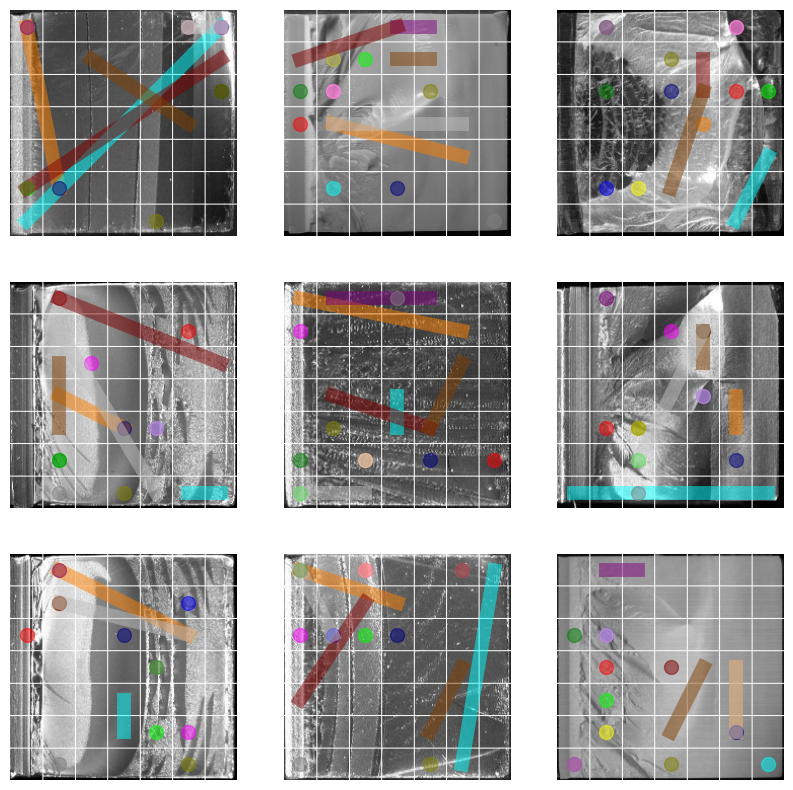

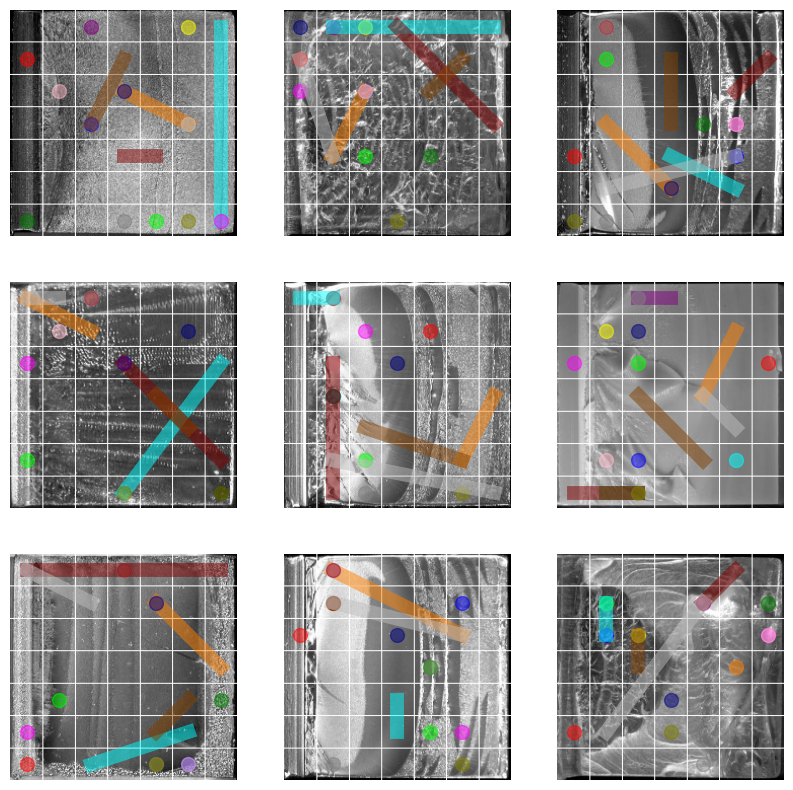

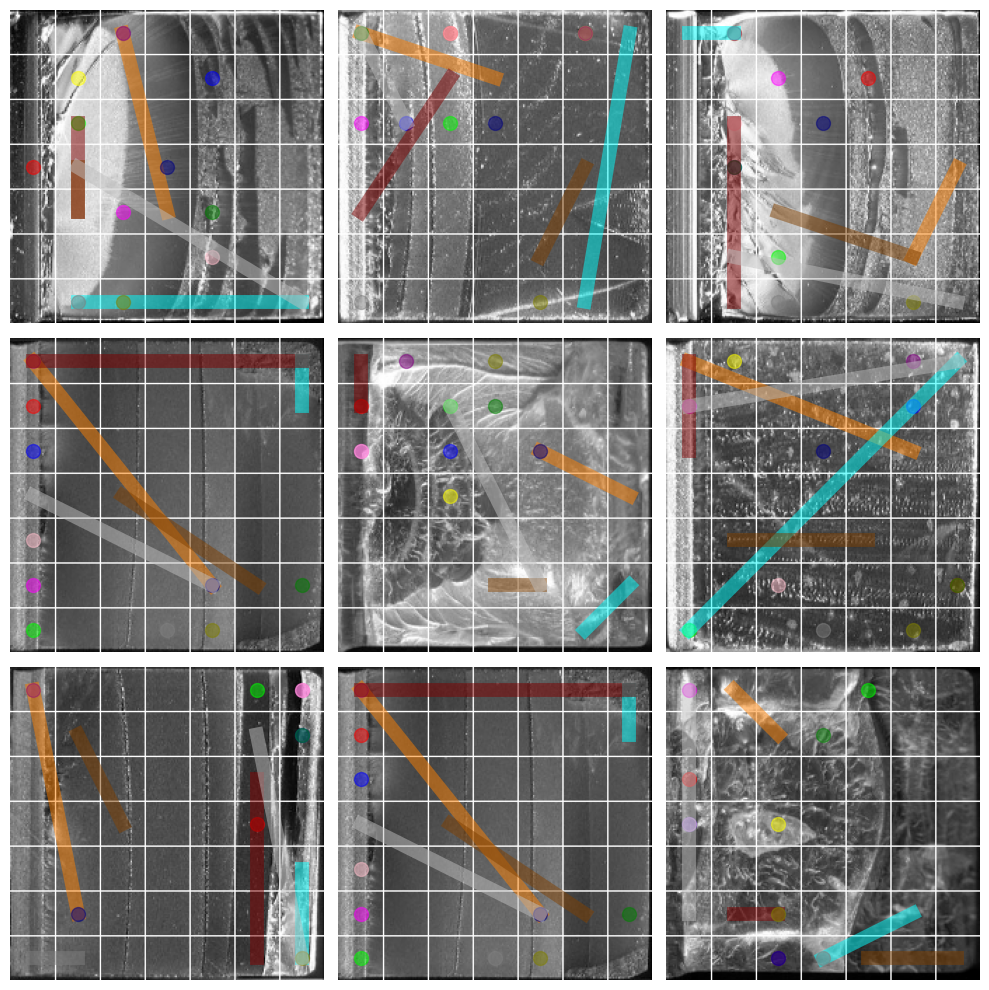

In [8]:
import numpy as np
import pandas as pd 
import pickle as pkl
import cv2
import matplotlib.pyplot as plt

# data
ad_npy = np.load('./Causal_Analysis/data/aw_allpth_ymax_4949_bootstrap.npy')
oof = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed42_bootstrap_oof_df.csv')
vit_oof = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed42_bootstrap_oof_df.csv')\
    .sort_values(by='Id').reset_index(drop=True)
f = open("./Mototake_Analysis/VGG+GP/Y_pred_rational_seed42.pkl","rb")
plot_Y_rational = pkl.load(f)
f.close()
oof['VGG+GP_preds'] = plot_Y_rational[1][3]
oof = oof.sort_values(by='Id').reset_index(drop=True)

# diff definition
num=27
oof['vgg_diff'] = abs(oof['preds'] - oof['KIc'])
vit_oof['vit_diff'] = abs(vit_oof['preds'] - vit_oof['KIc'])
vgg_gp = abs(oof['VGG+GP_preds'] - oof['KIc'])
vit_oof['vit_diff_from_vgg'] = vgg_gp - vit_oof['vit_diff']
vit_oof['vit_absdiff_from_vgg'] = abs(vgg_gp - vit_oof['vit_diff'])
better_id = vit_oof.nlargest(num, 'vit_diff_from_vgg')['Id']
better_ix = vit_oof.nlargest(num, 'vit_diff_from_vgg').index
worse_id = vit_oof.nsmallest(num, 'vit_absdiff_from_vgg')['Id']
worse_ix = vit_oof.nsmallest(num, 'vit_absdiff_from_vgg').index
step = 32
img_y, img_x = 224, 224

# color
colors = [
    (1.0, 0.0, 0.0, 0.5),   # 赤
    (0.0, 1.0, 0.0, 0.5),   # 緑
    (0.0, 0.0, 1.0, 0.5),   # 青
    (1.0, 1.0, 0.0, 0.5),   # 黄
    (1.0, 0.5, 0.0, 0.5),   # オレンジ
    (0.5, 0.0, 0.5, 0.5),   # 紫
    (0.0, 1.0, 1.0, 0.5),   # シアン
    (1.0, 0.0, 1.0, 0.5),   # マゼンタ
    (0.5, 0.5, 0.5, 0.5),   # グレー
    (1.0, 0.75, 0.8, 0.5),  # ピンク
    (0.0, 0.5, 0.0, 0.5),   # ダークグリーン
    (0.5, 0.0, 0.0, 0.5),   # ダークレッド
    (0.0, 0.0, 0.5, 0.5),   # ダークブルー
    (0.5, 0.5, 0.0, 0.5),   # オリーブ
    (0.5, 0.25, 0.0, 0.5),  # ブラウン
    (0.75, 0.75, 0.75, 0.5) # ライトグレー
]

vertical_length = 0
horizontal_length = 0

for n, (i, ix) in enumerate(zip(better_id.values.tolist(), better_ix)):
    if n % 9 == 0: fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    ax = axes[(n % 9) // 3, n % 3]
    path = '/home/yamanaka/Master_research/Mototake_Analysis/VGG+GP/imagedata/' + str(i) + '.jpg'
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_x, img_y))
    img[step:img_y:step, :, :] = 255
    img[:, step:img_x:step, :] = 255

    all_ad_max = 0
    all_ad = 0

    line_coordinates = []

    for j in range(16):
        ad = ad_npy[ix, j]
        # print(ad.shape)
        # print(ad)
        # for l in range(49):
        #     ad[l, l] = 0
        ad_max = ad.max()
        # print(ad_max)
        if ad_max > all_ad_max:
            all_ad_max = ad_max
            all_ad = ad
        xy = np.argmax(ad) 
        x, y = np.unravel_index(np.argmax(ad, axis=None), ad.shape)

        # print(x, y)
        # x, y = xy % 49, xy // 49
        # print(x, y)
        xi, xj = x%7, x//7
        yi, yj = y%7, y//7
        # print(f"Plotting line from ({xi, yi}) to ({xj, yj})")

        line_coordinates.append(f"{xi, xj}, {yi, yj}")
        vertical_length += abs(yi - yj)
        horizontal_length += abs(xi - xj)

        if x == y: 
            ax.plot((16+(32*xi)), (16+(32*xj)), color=colors[j], marker = 'o', markersize=10)
        else:
            ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=int(10))
        # if 30 <= ad_max < 60: ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=1)
        # if 60 <= ad_max < 90: ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=4)
        # if 90 <= ad_max : ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=10)
        
    # print(f"Image  {i}:")
    # print(line_coordinates)
    # xy = np.argmax(all_ad)
    # print(all_ad_max)
    # x, y = xy % 49, xy // 49
    # xi, xj = x%7, x//7
    # yi, yj = y%7, y//7
    # cv2.line(img, (16+(32*xi), 16+(32*xj)), (16+(32*yi), 16+(32*yj)), (255, 0, 0), thickness=3, lineType=cv2.LINE_4)
    ax.imshow(img)
    # ax.set_xlabel('x')  # X軸の名前を設定
    # ax.set_ylabel('y')  # Y軸の名前を設定
    # ax.grid(True)
    ax.axis('off')
    # if n == 8: break

print("縦：", vertical_length)
print("横：", horizontal_length)
print("比率：", horizontal_length / (vertical_length + horizontal_length))

plt.tight_layout()
# plt.savefig("./Figure/aw_surface.eps")
plt.show()

縦： 981
横： 958
比率： 0.49406910778751933


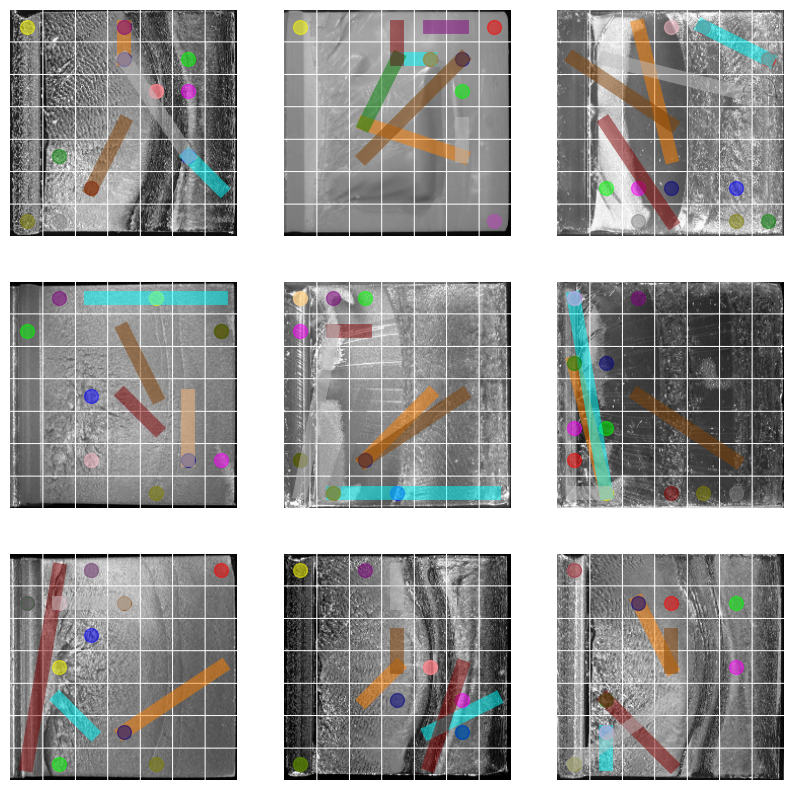

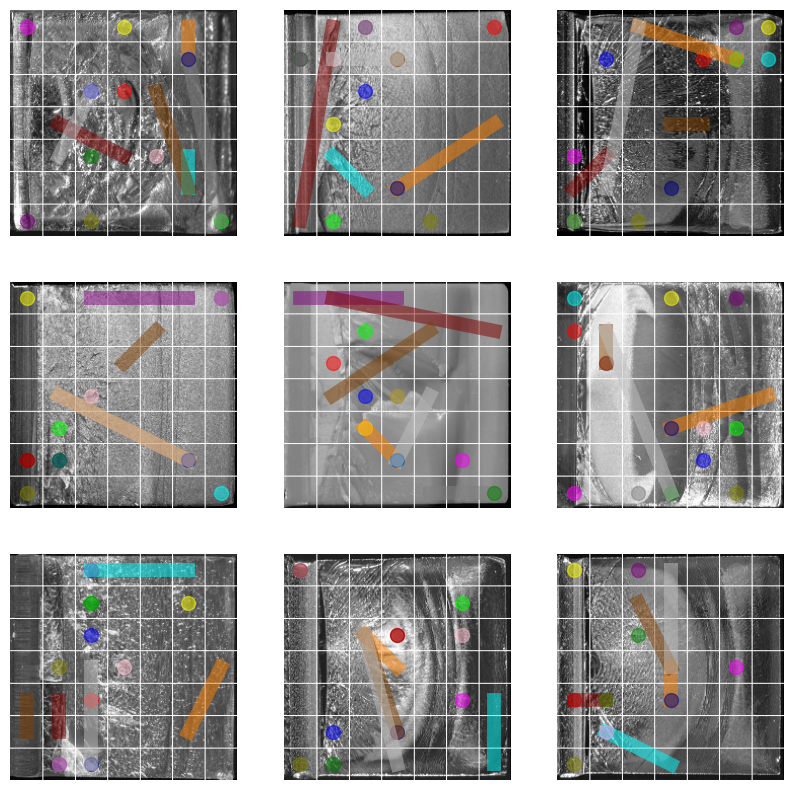

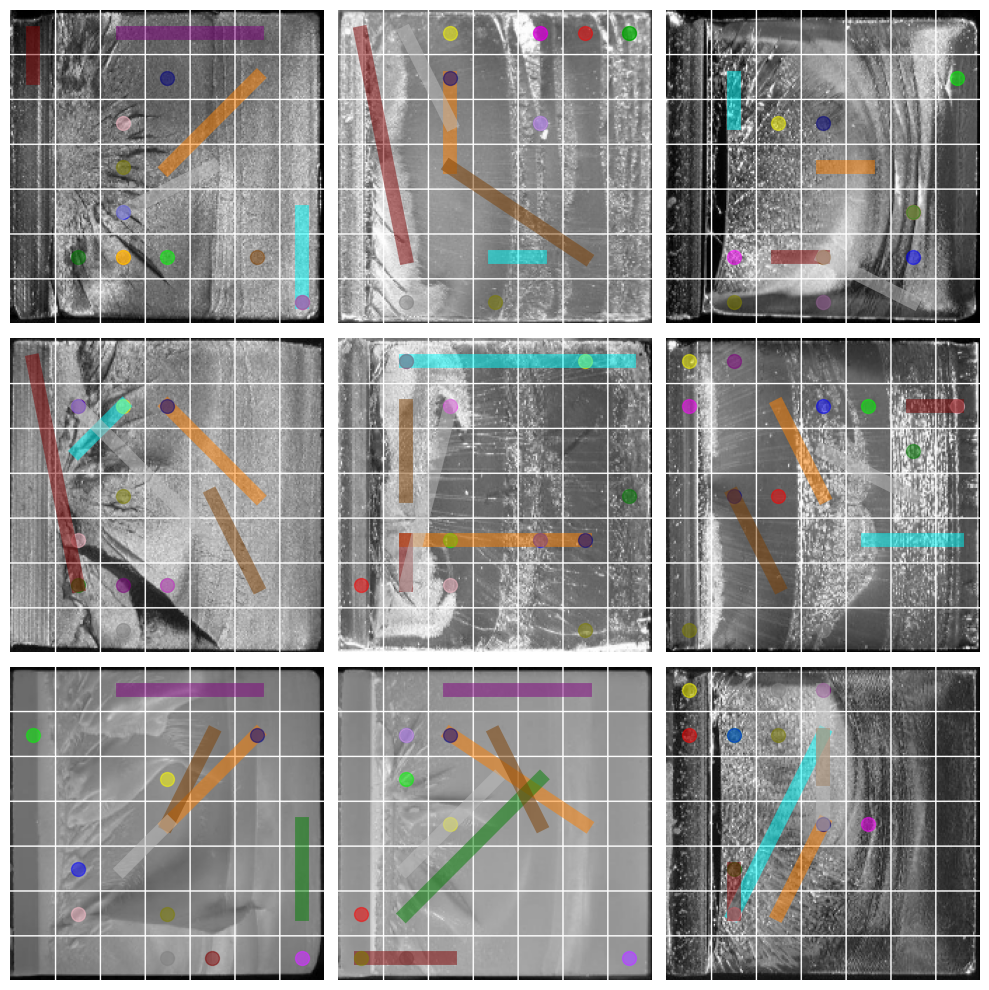

In [9]:
import numpy as np
import pandas as pd 
import pickle as pkl
import cv2
import matplotlib.pyplot as plt

# data
ad_npy = np.load('./Causal_Analysis/data/aw_allpth_ymax_4949_bootstrap.npy')
oof = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed42_bootstrap_oof_df.csv')
vit_oof = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed42_bootstrap_oof_df.csv')\
    .sort_values(by='Id').reset_index(drop=True)
f = open("./Mototake_Analysis/VGG+GP/Y_pred_rational_seed42.pkl","rb")
plot_Y_rational = pkl.load(f)
f.close()
oof['VGG+GP_preds'] = plot_Y_rational[1][3]
oof = oof.sort_values(by='Id').reset_index(drop=True)

# diff definition
num=27
oof['vgg_diff'] = abs(oof['preds'] - oof['KIc'])
vit_oof['vit_diff'] = abs(vit_oof['preds'] - vit_oof['KIc'])
vgg_gp = abs(oof['VGG+GP_preds'] - oof['KIc'])
vit_oof['vit_diff_from_vgg'] = vgg_gp - vit_oof['vit_diff']
vit_oof['vit_absdiff_from_vgg'] = abs(vgg_gp - vit_oof['vit_diff'])
better_id = vit_oof.nlargest(num, 'vit_diff_from_vgg')['Id']
better_ix = vit_oof.nlargest(num, 'vit_diff_from_vgg').index
worse_id = vit_oof.nsmallest(num, 'vit_absdiff_from_vgg')['Id']
worse_ix = vit_oof.nsmallest(num, 'vit_absdiff_from_vgg').index
step = 32
img_y, img_x = 224, 224

# color
colors = [
    (1.0, 0.0, 0.0, 0.5),   # 赤
    (0.0, 1.0, 0.0, 0.5),   # 緑
    (0.0, 0.0, 1.0, 0.5),   # 青
    (1.0, 1.0, 0.0, 0.5),   # 黄
    (1.0, 0.5, 0.0, 0.5),   # オレンジ
    (0.5, 0.0, 0.5, 0.5),   # 紫
    (0.0, 1.0, 1.0, 0.5),   # シアン
    (1.0, 0.0, 1.0, 0.5),   # マゼンタ
    (0.5, 0.5, 0.5, 0.5),   # グレー
    (1.0, 0.75, 0.8, 0.5),  # ピンク
    (0.0, 0.5, 0.0, 0.5),   # ダークグリーン
    (0.5, 0.0, 0.0, 0.5),   # ダークレッド
    (0.0, 0.0, 0.5, 0.5),   # ダークブルー
    (0.5, 0.5, 0.0, 0.5),   # オリーブ
    (0.5, 0.25, 0.0, 0.5),  # ブラウン
    (0.75, 0.75, 0.75, 0.5) # ライトグレー
]

vertical_length = 0
horizontal_length = 0

for n, (i, ix) in enumerate(zip(worse_id.values.tolist(), worse_ix)):
    if n % 9 == 0: fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    ax = axes[(n % 9) // 3, n % 3]
    path = '/home/yamanaka/Master_research/Mototake_Analysis/VGG+GP/imagedata/' + str(i) + '.jpg'
    
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_x, img_y))
    img[step:img_y:step, :, :] = 255
    img[:, step:img_x:step, :] = 255

    all_ad_max = 0
    all_ad = 0

    line_coordinates = []

    for j in range(16):
        ad = ad_npy[ix, j]
        # print(ad.shape)
        # print(ad)
        # for l in range(49):
        #     ad[l, l] = 0
        ad_max = ad.max()
        # print(ad_max)
        if ad_max > all_ad_max:
            all_ad_max = ad_max
            all_ad = ad
        xy = np.argmax(ad) 
        x, y = np.unravel_index(np.argmax(ad, axis=None), ad.shape)

        # print(x, y)
        # x, y = xy % 49, xy // 49
        # print(x, y)
        xi, xj = x%7, x//7
        yi, yj = y%7, y//7
        # print(f"Plotting line from ({xi, yi}) to ({xj, yj})")

        line_coordinates.append(f"{xi, xj}, {yi, yj}")
        vertical_length += abs(yi - yj)
        horizontal_length += abs(xi - xj)

        if x == y: 
            ax.plot((16+(32*xi)), (16+(32*xj)), color=colors[j], marker = 'o', markersize=10)
        else:
            ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=int(10))
        # if 30 <= ad_max < 60: ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=1)
        # if 60 <= ad_max < 90: ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=4)
        # if 90 <= ad_max : ax.plot((16+(32*xi), 16+(32*yi)), (16+(32*xj), 16+(32*yj)), color=colors[j], linewidth=10)
        
    # print(f"Image  {i}:")
    # print(line_coordinates)
    # xy = np.argmax(all_ad)
    # print(all_ad_max)
    # x, y = xy % 49, xy // 49
    # xi, xj = x%7, x//7
    # yi, yj = y%7, y//7
    # cv2.line(img, (16+(32*xi), 16+(32*xj)), (16+(32*yi), 16+(32*yj)), (255, 0, 0), thickness=3, lineType=cv2.LINE_4)
    ax.imshow(img)
    # ax.set_xlabel('x')  # X軸の名前を設定
    # ax.set_ylabel('y')  # Y軸の名前を設定
    # ax.grid(True)
    ax.axis('off')
    # if n == 8: break

print("縦：", vertical_length)
print("横：", horizontal_length)
print("比率：", horizontal_length / (vertical_length + horizontal_length))

plt.tight_layout()
# plt.savefig("./Figure/aw_surface.eps")
plt.show()